# California Housing Price Prediction

This notebook demonstrates a professional regression workflow for the California Housing dataset. It includes EDA, clean train/test splitting, feature engineering, baseline comparison, hyperparameter search, model evaluation, and interpretability.


## Project goals

- Predict median California house values using a robust regression workflow.
- Avoid data leakage using stratified sampling by income category.
- Compare SVR against strong baselines and tune the model with cross-validation.
- Present clean visualizations, reusable functions, and clear evaluation metrics.


In [6]:
import logging
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score)
from sklearn.model_selection import (RandomizedSearchCV, StratifiedShuffleSplit,
                                     cross_val_score, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.svm import SVR

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s %(levelname)s: %(message)s',
                    datefmt='%Y-%m-%d %H:%M:%S')


## Imports and logging

We configure a reproducible data science environment and a simple logger for runtime feedback.


In [7]:
def load_housing_data() -> pd.DataFrame:
    dataset_path = Path('data') / 'california_housing.csv'
    if dataset_path.exists():
        logging.info('Loading dataset from %s', dataset_path)
        return pd.read_csv(dataset_path)

    try:
        from sklearn.datasets import fetch_california_housing

        logging.info('Downloading California Housing dataset using scikit-learn')
        frame = fetch_california_housing(as_frame=True).frame
        frame.columns = frame.columns.str.replace(' ', '_')
        return frame
    except Exception as exc:
        logging.warning('scikit-learn dataset fetch failed: %s', exc)
        fallback_url = (
            'https://raw.githubusercontent.com/ageron/handson-ml3/'
            'main/datasets/housing/housing.csv'
        )
        logging.info('Loading California Housing dataset from fallback URL: %s', fallback_url)
        try:
            return pd.read_csv(fallback_url)
        except Exception as fallback_exc:
            raise RuntimeError(
                'Unable to load the California Housing dataset. '
                'Provide data/california_housing.csv or enable network access for the fallback URL.'
            ) from fallback_exc


def add_income_category(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['income_cat'] = pd.cut(
        df['MedInc'],
        bins=[0.0, 1.5, 3.0, 4.5, 6.0, np.inf],
        labels=[1, 2, 3, 4, 5]
    )
    return df


def stratified_train_test_split(df: pd.DataFrame, test_size: float = 0.2, random_state: int = 42):
    split = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    for train_index, test_index in split.split(df, df['income_cat']):
        train_set = df.loc[train_index].copy()
        test_set = df.loc[test_index].copy()
    for dataset in (train_set, test_set):
        dataset.drop(columns=['income_cat'], inplace=True)
    return train_set, test_set


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['rooms_per_household'] = df['AveRooms'] / df['AveOccup']
    df['bedrooms_per_room'] = df['AveBedrms'] / df['AveRooms']
    df['population_per_household'] = df['Population'] / df['AveOccup']
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    return df.fillna(0)


def build_preprocessing_pipeline() -> Pipeline:
    return Pipeline([
        ('feature_engineering', FunctionTransformer(add_features, validate=False)),
        ('scaler', StandardScaler())
    ])


def evaluate_regression_model(name: str, model, X: pd.DataFrame, y: pd.Series):
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    logging.info('%s test results: R2=%.4f RMSE=%.4f MAE=%.4f', name, r2, rmse, mae)
    return {
        'model': name,
        'R2': r2,
        'RMSE': rmse,
        'MAE': mae,
        'predictions': y_pred
    }


def cross_validate_model(name: str, model, X: pd.DataFrame, y: pd.Series, cv: int = 5):
    scoring = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error']
    scores = {
        'R2': cross_val_score(model, X, y, scoring='r2', cv=cv, n_jobs=-1),
        'RMSE': -cross_val_score(model, X, y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=-1),
        'MAE': -cross_val_score(model, X, y, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1),
    }
    print(f'{name} cross-validation results:')
    for metric, values in scores.items():
        print(f'  {metric}: {values.mean():.4f} ± {values.std():.4f}')
    return scores


## Helper functions

These functions load the dataset, perform stratified splitting, generate feature ratios, and standardize the pipeline. This keeps the notebook reusable and avoids duplicated preprocessing logic.


In [8]:
housing = load_housing_data()
housing.head()


2026-08-03 09:38:25 INFO: Downloading California Housing dataset using scikit-learn


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Dataset overview

Load the California Housing dataset and inspect the first rows.


In [9]:
housing.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


### Missing values and duplicates

We verify that the dataset contains no missing or duplicate records before modeling.


In [10]:
print('Missing values per column:')
print(housing.isnull().sum())
print('\nDuplicate rows:', housing.duplicated().sum())


Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Duplicate rows: 0


In [11]:
housing.describe().T


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


### Feature distributions

We visualize the distribution of key numeric features and the target variable.


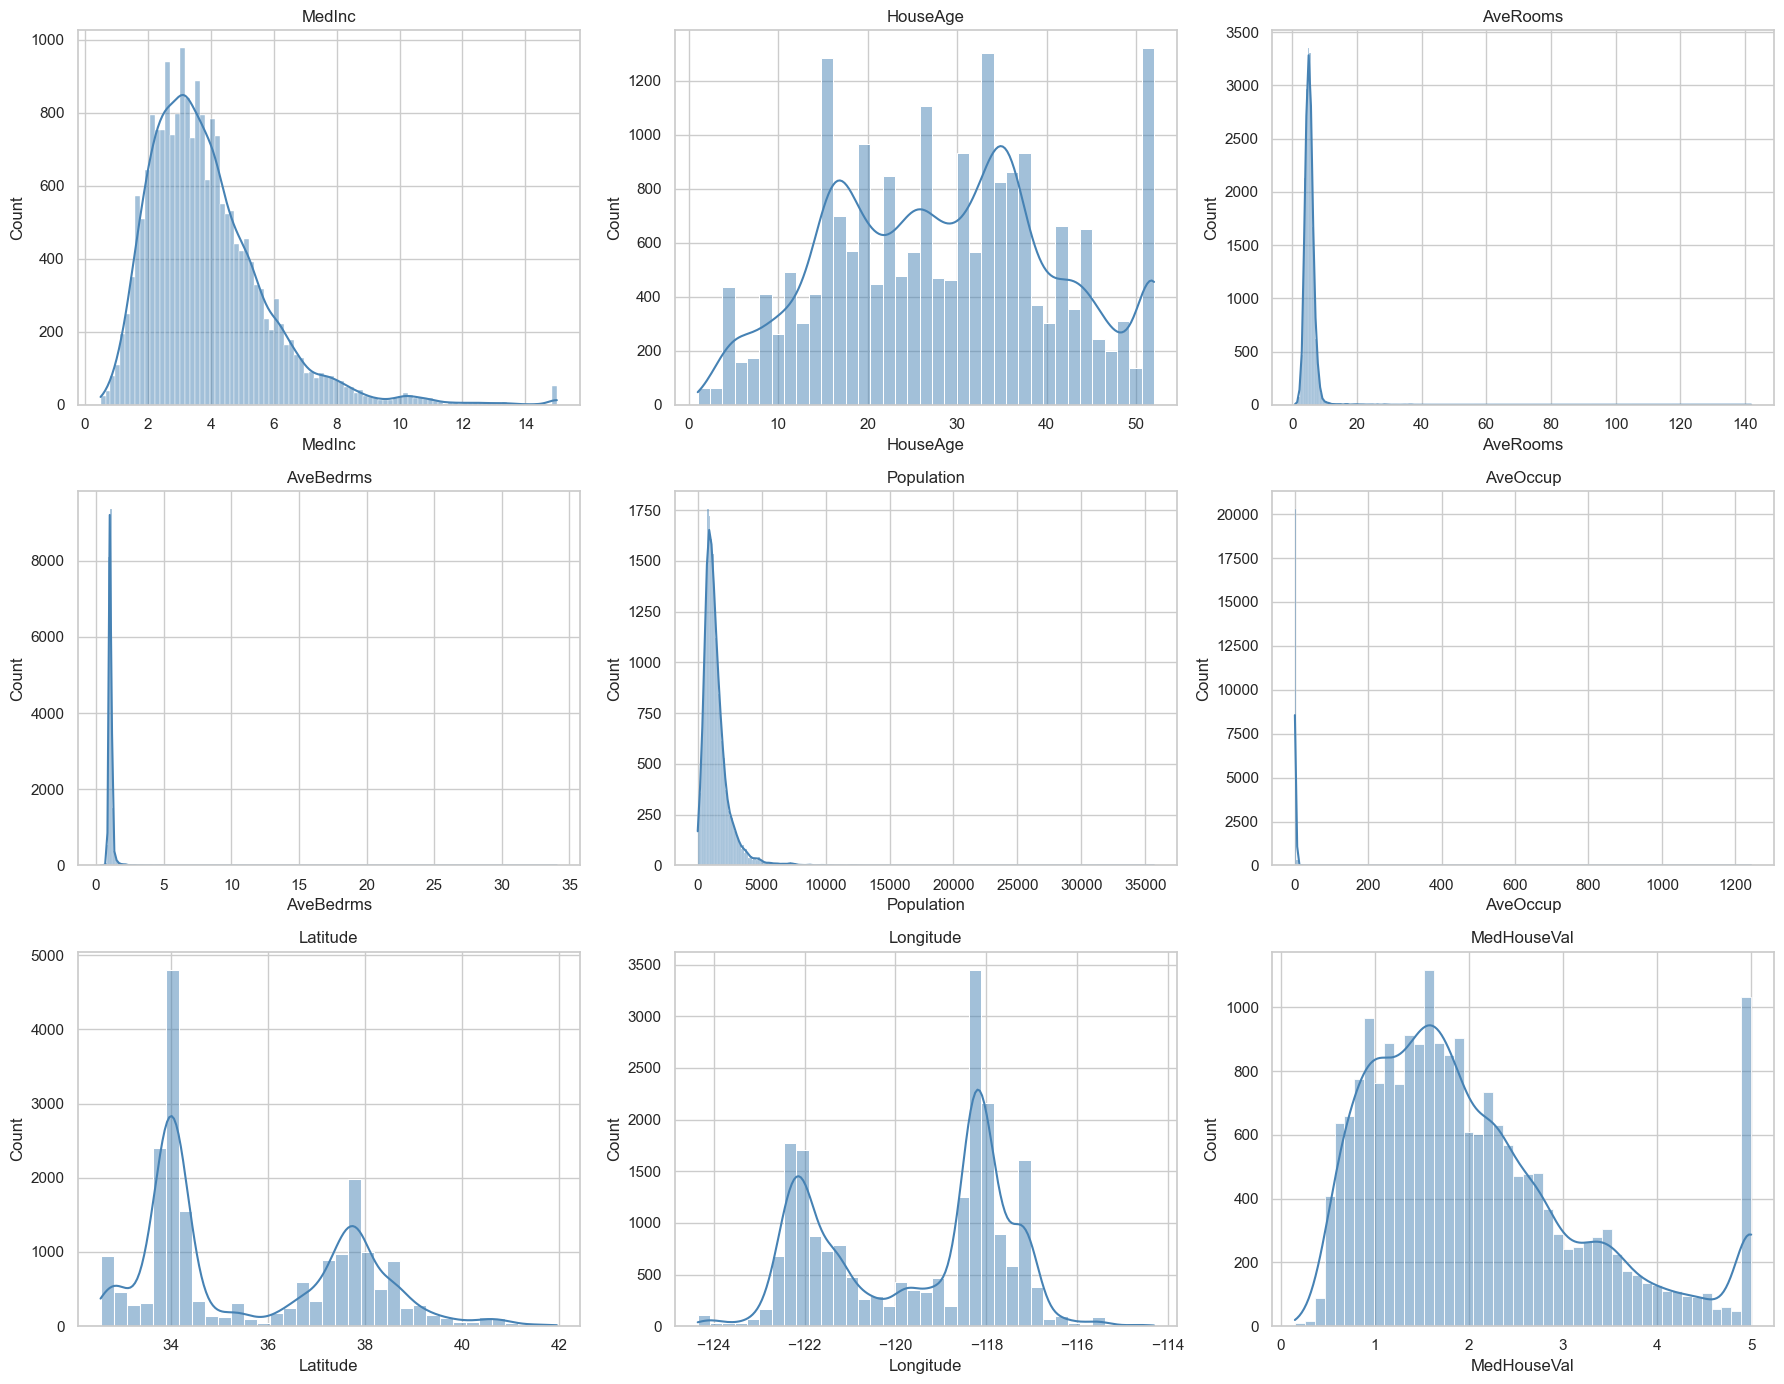

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
columns = housing.columns.tolist()
for ax, col in zip(axes.flatten(), columns):
    sns.histplot(housing[col], ax=ax, kde=True, color='steelblue')
    ax.set_title(col)
plt.tight_layout()


### Correlation matrix

A correlation heatmap identifies the strongest linear relationships and guides model interpretation.


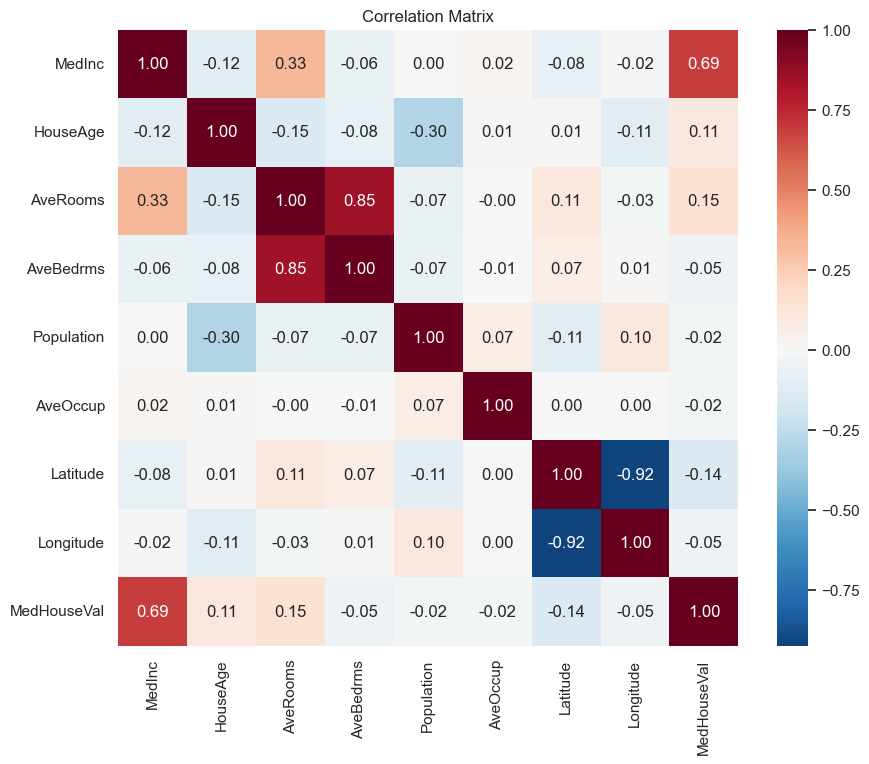

In [13]:
corr_matrix = housing.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlation Matrix')
plt.show()


### Geographic distribution

Scatter plots show how median house values vary with location.


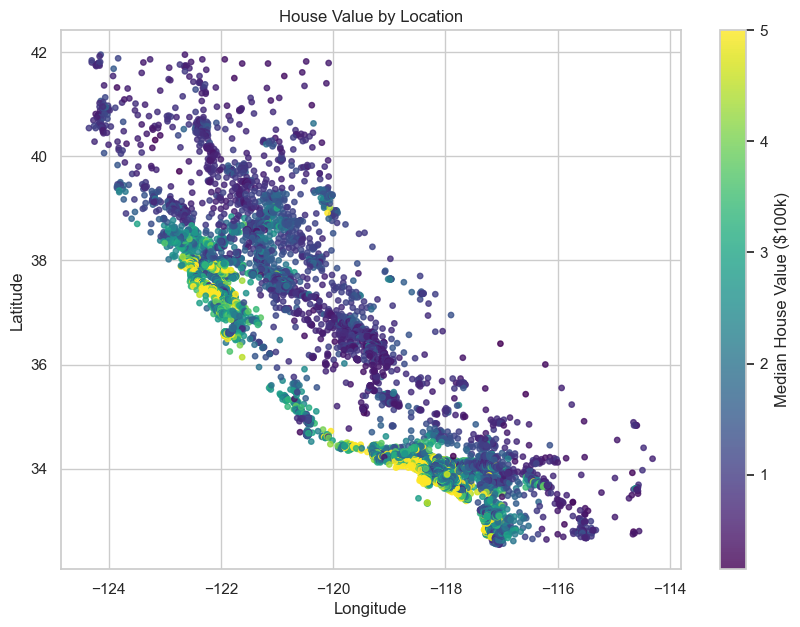

In [14]:
plt.figure(figsize=(10, 7))
plt.scatter(housing['Longitude'], housing['Latitude'], c=housing['MedHouseVal'], cmap='viridis', s=15, alpha=0.8)
plt.colorbar(label='Median House Value ($100k)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('House Value by Location')
plt.show()


In [ ]:
plt.figure(figsize=(10, 7))
prices_by_location = housing.groupby(['Latitude', 'Longitude'])['MedHouseVal'].median().reset_index()
plt.scatter(prices_by_location['Longitude'], prices_by_location['Latitude'],
            c=prices_by_location['MedHouseVal'], cmap='viridis', s=20)
plt.colorbar(label='Median House Value ($100k)')
plt.title('Median House Value by Location')
plt.show()


## Train-test split

We apply stratified sampling on income category to preserve the distribution of household income in both the train and test sets.


In [15]:
housing_with_cat = add_income_category(housing)
train_set, test_set = stratified_train_test_split(housing_with_cat)
print('Train shape:', train_set.shape)
print('Test shape :', test_set.shape)
print('\nIncome category distribution in train set:')
print(housing_with_cat.loc[train_set.index, 'income_cat'].value_counts(normalize=True))


Train shape: (16512, 9)
Test shape : (4128, 9)

Income category distribution in train set:
income_cat
3    0.350594
2    0.318859
4    0.176296
5    0.114462
1    0.039789
Name: proportion, dtype: float64


## Prepare data for modeling

Drop the target from the training set and build a reusable preprocessing pipeline.


In [16]:
X_train = train_set.drop('MedHouseVal', axis=1)
y_train = train_set['MedHouseVal']
X_test = test_set.drop('MedHouseVal', axis=1)
y_test = test_set['MedHouseVal']

preprocessor = build_preprocessing_pipeline()
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)
print('Prepared feature shape:', X_train_prepared.shape)


Prepared feature shape: (16512, 11)


## Baseline models

We compare Linear Regression, Random Forest, and Support Vector Regression with the same preprocessing pipeline.


In [ ]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
])
svr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', SVR())
])

baseline_models = {
    'Linear Regression': lr_pipeline,
    'Random Forest': rf_pipeline,
    'SVR (default)': svr_pipeline,
}

baseline_scores = {}
for name, model in baseline_models.items():
    baseline_scores[name] = cross_validate_model(name, model, X_train, y_train)


## Fit baseline models on full training data

The baseline pipelines are fit on the complete training set so we can compare hold-out test performance.


In [ ]:
fitted_models = {}
for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model

results = []
for name, model in fitted_models.items():
    evaluation = evaluate_regression_model(name, model, X_test, y_test)
    results.append(evaluation)

results_df = pd.DataFrame(results).drop(columns=['predictions'])
results_df


## Hyperparameter tuning

Use randomized search to find an improved SVR configuration without overfitting the training data.


In [ ]:
param_distributions = {
    'regressor__C': [0.5, 1.0, 2.5, 5.0, 10.0, 20.0],
    'regressor__epsilon': [0.01, 0.05, 0.1, 0.2, 0.3],
    'regressor__kernel': ['rbf', 'linear'],
    'regressor__gamma': ['scale', 'auto'],
}
search_pipeline = Pipeline([
    ('preprocessor', build_preprocessing_pipeline()),
    ('regressor', SVR())
])

random_search = RandomizedSearchCV(
    search_pipeline,
    param_distributions,
    n_iter=25,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)
print('Best parameters:', random_search.best_params_)
print('Best CV RMSE:', -random_search.best_score_)


## Evaluate the tuned SVR model

Compare the tuned SVR against the baseline models on the hold-out test set.


In [ ]:
best_svr = random_search.best_estimator_
best_svr_results = evaluate_regression_model('SVR (tuned)', best_svr, X_test, y_test)
results_df = pd.concat([
    results_df,
    pd.DataFrame([ {k: v for k, v in best_svr_results.items() if k != 'predictions'} ])
], ignore_index=True)
results_df


## Residual analysis

Residual plots help detect heteroscedasticity and systematic prediction errors.


In [ ]:
y_pred_best = best_svr.predict(X_test)
residuals = y_test - y_pred_best
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_best, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Median House Value ($100k)')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted Values')
plt.show()


In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='purple', bins=30)
plt.title('Residual Distribution')
plt.xlabel('Residual')
plt.show()


## Permutation feature importance

This model-agnostic check highlights the features that most affect SVR predictions.


In [ ]:
perm_importance = permutation_importance(
    best_svr, X_test, y_test, n_repeats=15, random_state=42, n_jobs=-1
)
feature_names = X_test.columns.tolist()
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std,
}).sort_values(by='importance_mean', ascending=False)
importance_df.head(10)


In [ ]:
plt.figure(figsize=(10, 6))
 sns.barplot(
    data=importance_df.head(10),
    x='importance_mean',
    y='feature',
    palette='mako'
)
plt.title('Top 10 Permutation Feature Importances')
plt.xlabel('Mean importance')
plt.ylabel('Feature')
plt.show()


## Conclusion

The notebook compares a tuned SVR model with baseline regressors, uses stratified train/test splitting to reduce sampling bias, and evaluates performance with R², RMSE, and MAE. The model pipeline is reproducible and avoids data leakage by applying all feature transformations inside sklearn pipelines.
